# Project D0042E
## Task 1 (Data exploration)
Loads labeled_data.csv into a pandas DataFrame and parses timestamp_utc as the index.

In [63]:
import pandas as pd

df = pd.read_csv('labeled_data.csv')
# Convert timestamp column from a string to datetime format
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
df = df.set_index("timestamp_utc")

Reports the shape of the DataFrame, the time span it covers, and number of fault episodes.

In [64]:
print(df.columns)
print("Amount of samples:",len(df))

duration = df.index.max() - df.index.min()
print("Duration:", duration)

faults = df[df["fault_active"] == 1]
# Counts number of faults by identifying time gaps bigger then 20s
num_faults = (faults.index.to_series().diff() > pd.Timedelta("20s")).sum()+1
print(f"Number faults: {num_faults}")

Index(['ts_ms', 'temperature/room1', 'temperature/room2', 'temperature/room3',
       'temperature/supply', 'temperature/outside', 'flow/room1', 'flow/room2',
       'flow/room3', 'return/room1', 'return/room2', 'return/room3',
       'fault_active', 'fault_type', 'fault_room'],
      dtype='str')
Amount of samples: 80640
Duration: 13 days 23:59:45
Number faults: 135


Creates a subset of the DataFrame that only contains data from 2026-04-15.

In [65]:
df_subset = df[df.index.date == pd.to_datetime("2026-04-15").date()]

Plots the time series of all 11 sensor channels, separated by room. The fault intervals are shaded and color-coded by  fault type, either window_open as blue or radiator_blocked as red. 

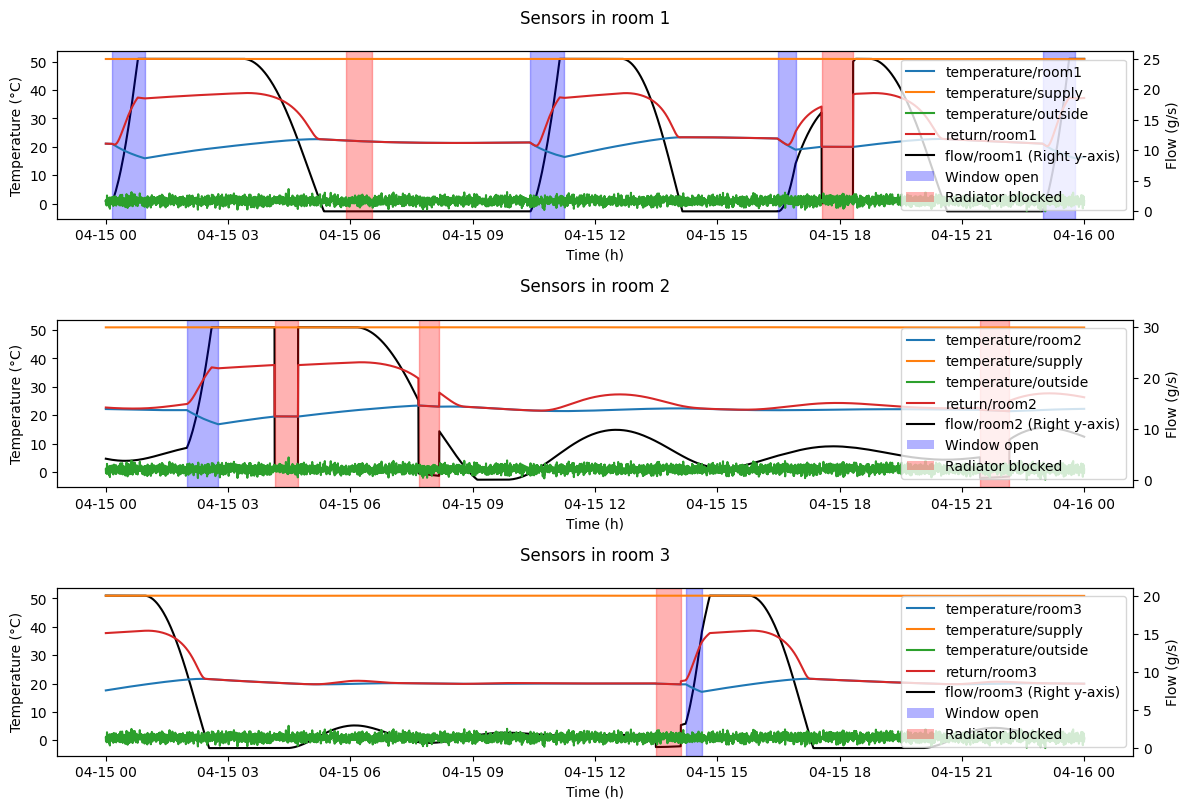

In [66]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

cols = [
    "temperature/room",
    "temperature/supply",
    "temperature/outside",
    "flow/room",
    "return/room",
]

fault_colors = {
    "window_open":"blue",
    "radiator_blocked":"red"
}

fig, axes = plt.subplots(3,1)
fig.set_size_inches(12,8)

for i, ax in enumerate(axes):
    #Creates second y-axis
    ax2 = ax.twinx()  
    ax.set_zorder(2)
    ax2.set_zorder(1)
    ax.patch.set_visible(False)
    
    for col in cols:
        if col[-4:] == "room":
            col += str(i+1)
        if "flow" in col:
            ax2.plot(df_subset[col]*1000, color="black", label= ("flow/room"+ str(i+1)+ " (Right y-axis)"))
        else:
            ax.plot(df_subset[col], label=col)

    # Identifies fault windows
    faults = df_subset[df_subset["fault_room"] == f"room{i+1}"]
    groups = (faults.index.to_series().diff() > pd.Timedelta("20s")).cumsum()

    #Shade fault windows
    for _, g in faults.groupby(groups):
        ax.axvspan(
            g.index.min(),
            g.index.max(),
            color=fault_colors[g["fault_type"].iloc[0]],
            alpha=0.3
        )
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.6)

    ax.set_title(f"Sensors in room {i+1}",pad=20)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Temperature (°C)")
    ax2.set_ylabel("Flow (g/s)")

    fault_patches = [
        Patch(facecolor="blue", alpha=0.3, label="Window open"),
        Patch(facecolor="red", alpha=0.3, label="Radiator blocked")
    ]
    
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2 + fault_patches, labels + labels2 + [p.get_label() for p in fault_patches])

plt.show()

## Task 2 (Feature Engineering)

Builds a binary target vector.

In [67]:
import numpy as np

y = np.where(df["fault_type"].isna(), 0, 1)

Builds a feature matrix X from raw values, setpoint errors and cross-channel features (supply minus return per room, and an approximate
radiator power). 

In [68]:
feature_cols = [
    "temperature/room1",
    "temperature/room2",
    "temperature/room3",
    "temperature/supply",
    "temperature/outside",
    "flow/room1",
    "flow/room2",
    "flow/room3",
    "return/room1",
    "return/room2",
    "return/room3",
]

# Features from raw values
X_raw = df[feature_cols].to_numpy()
# Features from setpoint errors
X_sp_err = np.array([[21,22,20]]) - X_raw[:,0:3]
# Cross-channel features
X_P = X_raw[:,5:8]*(X_raw[:,3:4] - X_raw[:,-3:])

# Combine features
X = np.concatenate([X_raw, X_sp_err, X_P],axis=1)

Reports the dataset shape and the class balance. 

In [69]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

no_fault = (y == 0).sum()/len(y)
fault = (y == 1).sum()/len(y)

print(f"Class balance:")
print(f"No faults: {no_fault}")
print(f"Fault: {fault}")

X shape: (80640, 17)
y shape: (80640,)
Class balance:
No faults: 0.7442212301587302
Fault: 0.25577876984126985


## Task 3 (Train and Evaluate the Detector) 
Splits the dataset chronologically into training, validation, and test sets.

In [70]:
split_index_1 = int(len(y)*0.7)
split_index_2 = int(len(y)*0.85)

# Splits into 70% training data, 15% validation data, 15% test data
X_train = X[0:split_index_1,:]
y_train = y[0:split_index_1]

X_val = X[split_index_1:split_index_2,:]
y_val = y[split_index_1:split_index_2]

X_test = X[split_index_2:,:]
y_test = y[split_index_2:]

This block imports all required libraries.

In [71]:
# Imports PyTorch, NN module, functions, random seeds, tools for handling datasets and batching, and standardscalar
import torch
import torch.nn as nn
import random
random.seed(1234)
torch.manual_seed(1234)
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Imports a function to create a deep copy of an object
from copy import deepcopy

Defines architecture of the LSTM using a custom class called FaultNet, which inherits from torch.nn.Module.

In [72]:
# Defines neural network class and inherits from nn.Module
class FaultNet(nn.Module):
    def __init__(self, n_features, n_outputs):
        super().__init__() # Calls parent class (nn.Module) constructor
        
        # Creates an LSTM
        self.lstm = nn.LSTM(n_features,16,batch_first=True)

        # Creates an ReLU activation function
        self.relu = nn.ReLU()

        # Creates an Fully Connected Neural Network
        self.fc = nn.Linear(16,n_outputs)
        
    # Defines how data flows through the model
    def forward(self, x):
        # x shape: (BATCH_SIZE,SEQ_LENGTH,n_features)
        x, _ = self.lstm(x)
        # x shape: (BATCH_SIZE,SEQ_LENGTH,16)
        x = self.relu(x)
        # x shape: (BATCH_SIZE,SEQ_LENGTH,16)
        x = self.fc(x)
        # x shape: (BATCH_SIZE,SEQ_LENGTH,n_outputs)
        return x

This block performs standardization and converts numpy arrays to torch tensors. 

In [73]:
# Feature standardization on training data to prevent data leakage
scaler = StandardScaler()
scaler.fit(X_train)

# Convert numpy arrays to scaled torch tensors

X_train_tensor = torch.tensor(scaler.transform(X_train),dtype=torch.float32)
y_train_tensor = torch.tensor(y_train)

X_val_tensor = torch.tensor(scaler.transform(X_val),dtype=torch.float32)
y_val_tensor = torch.tensor(y_val)

X_test_tensor = torch.tensor(scaler.transform(X_test),dtype=torch.float32)
y_test_tensor = torch.tensor(y_test)

Initializes the model and defines the training configuration.

In [74]:
# Creates neural network with 17 features and 2 classes
model = FaultNet(17,2)

# Class weighting in the loss
# Idea: rare classes should have higher weight, common classes lower weight
freq = torch.tensor([no_fault, fault])
weights = (1.0 / freq).float()

# Normalize weights so that their mean equals 1
# This keeps the overall loss scale stable while preserving the relative class importance
weights = weights / weights.sum() * len(freq)

# Defines loss function with weights, CrossEntropyLoss for classification
criterion = nn.CrossEntropyLoss(weight=weights)

# Defines how many samples are processed per training step, more samples gives more stable gradients
BATCH_SIZE = 128

# Length of sample sequences extracted from the training set
SEQ_LENGTH = 64

# Creates the optimization algorithm (Adaptive Moment Estimation), updates the model’s parameters during training, lr = learning rate (steps), weight_decay penalizes high weights
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=0.025)

# Defines how many times the model will get a new batch
iterations = 1000

Defines function get_batch that creates a random batch from X and y.

In [75]:
# Tracks best model during training
best_loss = float('inf')
best_model = None

# A function that creates a random batch from X and y
def get_batch(X,y, batch_size, seq_length):

    # Define lists to store each sample of the batch
    features = []
    targets = []

    # Iterate once for each sample in batch
    for batch_nr in range(batch_size):

        # Creates a start and end index used for extracting a shorter sequence for X and y
        start_idx = random.randint(0,X.shape[0]-seq_length)
        end_index = start_idx+seq_length

        # Use start and end indexs and add to lists
        features.append(X[start_idx:end_index,:])
        targets.append(y[start_idx:end_index])

    # Stack the lists with smaples of shape (SEQ_LENGTH, 17) for features and (SEQ_LENGTH) for targets into 
    # (BATCH_SIZE, SEQ_LENGTH, 17) for features and (BATCH_SIZE, SEQ_LENGTH)
    return torch.stack(features,dim=0), torch.stack(targets,dim=0)

This block contains the full training and validation loop.

Iteration [50/1000] Training Loss: 0.5592 Validation Loss: 0.5715
Iteration [100/1000] Training Loss: 0.5864 Validation Loss: 0.5120
Iteration [150/1000] Training Loss: 0.4627 Validation Loss: 0.4929
Iteration [200/1000] Training Loss: 0.4814 Validation Loss: 0.5183
Iteration [250/1000] Training Loss: 0.4394 Validation Loss: 0.5032
Iteration [300/1000] Training Loss: 0.3648 Validation Loss: 0.4893
Iteration [350/1000] Training Loss: 0.3849 Validation Loss: 0.5600
Iteration [400/1000] Training Loss: 0.3558 Validation Loss: 0.5400
Iteration [450/1000] Training Loss: 0.3118 Validation Loss: 0.5137
Iteration [500/1000] Training Loss: 0.3348 Validation Loss: 0.5449
Iteration [550/1000] Training Loss: 0.3176 Validation Loss: 0.5263
Iteration [600/1000] Training Loss: 0.2854 Validation Loss: 0.5853
Iteration [650/1000] Training Loss: 0.2875 Validation Loss: 0.5679
Iteration [700/1000] Training Loss: 0.2010 Validation Loss: 0.5971
Iteration [750/1000] Training Loss: 0.2486 Validation Loss: 0.5

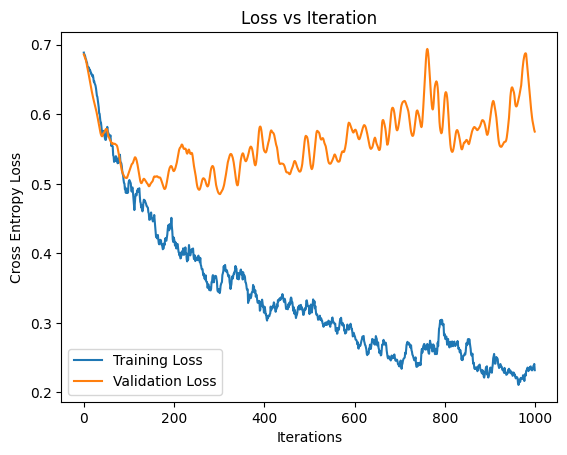

In [76]:
# Creates list to track losses
training_losses = []
validation_losses = []

for iteration in range(iterations):
    
    # Puts the model into training mode
    model.train()

    # Randomly create a batch
    features, targets = get_batch(X_train_tensor, y_train_tensor, BATCH_SIZE, SEQ_LENGTH)
    
    # features shape: (BATCH_SIZE,SEQ_LENGTH,17)
    # targets shape: (BATCH_SIZE,SEQ_LENGTH)
    
    # Forward pass
    predictions = model(features)
    # predictions shape: (BATCH_SIZE,SEQ_LENGTH,2)

    ## Calculate loss
    # Permute prediction to make them fit criterion
    predictions = torch.permute(predictions, (0,2,1))
    # predictions shape: (BATCH_SIZE,2,SEQ_LENGTH)
    training_loss = criterion(predictions, targets)

    # Add loss to list for plotting
    training_losses.append(training_loss.item())

    # Backpropagation
    training_loss.backward()

    # Update weights
    optimizer.step()

    # Clear gradients
    optimizer.zero_grad()
    
    # Puts the model into evaluation mode
    model.eval()

    # Add dim to validation features and target (BATCH_SIZE = 1)
    features = X_val_tensor[None,:,:]
    targets = y_val_tensor[None,:]
    # features shape: (1,LENGTH,17)
    # targets shape: (1,LENGTH)
        
    # Forward pass, disable gradient computation
    with torch.no_grad():
        predictions = model(features)

    ## Calculate loss
    # Permute prediction to make them fit criterion
    predictions = torch.permute(predictions, (0,2,1))
    # predictions shape: (1,2,LENGTH)
    validation_loss = criterion(predictions, targets)

    # Add loss to list for plotting
    validation_losses.append(validation_loss.item())

    # Saves best model
    if validation_loss<best_loss:
        best_loss = validation_loss
        best_model = deepcopy(model)
    
    # Print loss every 50:th iteration
    if (iteration+1)%50 == 0:
        print(f"Iteration [{iteration+1}/{iterations}] Training Loss: {training_loss:.4f} Validation Loss: {validation_loss:.4f}")


# Function that smooths the input through a moving average
def smooth(lst, w):
    smoothed = []

    for i in range(len(lst)):
        # Define window start/stop
        start = max(0, i - w // 2)
        end = min(len(lst), i + w // 2 + 1)

        # crop a window and average it
        window = lst[start:end]
        smoothed.append(sum(window) / len(window))

    return smoothed

# Plot loss curves
smoothed_training_loss = smooth(training_losses,11)
plt.plot(smoothed_training_loss, label = "Training Loss")
smoothed_validation_losses = smooth(validation_losses,11)
plt.plot(smoothed_validation_losses, label = "Validation Loss")
plt.ylabel("Cross Entropy Loss")
plt.xlabel("Iterations")
plt.title("Loss vs Iteration")
plt.legend()
plt.show()

Evaluation of the model on the test set using several metrics, including accuracy, precision, recall, F1-score, and the confusion matrix.

In [77]:
# Initialize confusion matrix
confusion_matrix = np.zeros((2,2))

# Puts the model into evaluation mode
model.eval()

features = X_test_tensor[None,:,:]
targets = y_test_tensor[None,:]
# features shape: (1, LENGTH, 17)
# targets shape: (1, LENGTH)
    
# Forward pass, disable gradient computation
with torch.no_grad():
    predictions = best_model(features)
# predictions shape: (1, LENGTH, 2)

# Forward pass, also picks the index of the highest score per sample
predictions = torch.argmax(predictions,2)
# predictions shape: (1, LENGTH)

# Remove all dimensions of length 1
predictions = torch.squeeze(predictions)
targets = torch.squeeze(targets)
# predictions shape: (LENGTH,)
# targets shape: (LENGTH,)

# Each iteration handles one sample
for p, t in zip(predictions,targets):
    # Updates confusion matrix
    confusion_matrix[t,p]+=1
    
# True is rows (left in matrix) and predicted is columns (up in matrix)
def print_metrics(confusion_matrix):
    print("Confusion_matrix:")
    print(confusion_matrix.astype(int))
    print("Accuracy:")
    print(f"{np.sum(confusion_matrix*np.eye(2))*100/np.sum(confusion_matrix):.1f} %")
    print("Precision (per class):")
    precisions = confusion_matrix[np.eye(2,dtype=bool)]/np.sum(confusion_matrix,axis=0)
    print(precisions)
    print("Recall (per class):")
    recalls = confusion_matrix[np.eye(2,dtype=bool)]/np.sum(confusion_matrix,axis=1)
    print(recalls)
    print("F1 score (per class):")
    F1_scores = (2*precisions*recalls)/(precisions+recalls)
    print(F1_scores)
    print("Mean F1 score:") 
    print(np.mean(F1_scores))
print_metrics(confusion_matrix)

Confusion_matrix:
[[7392 1217]
 [1371 2116]]
Accuracy:
78.6 %
Precision (per class):
[0.84354673 0.63486349]
Recall (per class):
[0.85863631 0.60682535]
F1 score (per class):
[0.85102464 0.62052786]
Mean F1 score:
0.7357762482924962


## Random Forest Classifier
Trains a random forest and evaluates the model on the same test data.

In [78]:
from sklearn.ensemble import RandomForestClassifier

#Uses same weights as previous model
cw = {0:weights[0],1:weights[1]}
#Uses random seeds to always create the same classifier
clf = RandomForestClassifier(max_depth=4,class_weight=cw, random_state=1234)
#Trains the model
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

confusion_matrix = np.zeros((2,2))
for p, t in zip(y_pred,y_test):
    confusion_matrix[t,p]+=1
print_metrics(confusion_matrix)

Confusion_matrix:
[[4979 3630]
 [1187 2300]]
Accuracy:
60.2 %
Precision (per class):
[0.8074927  0.38785835]
Recall (per class):
[0.57834824 0.65959277]
F1 score (per class):
[0.67397631 0.48847828]
Mean F1 score:
0.5812272976456339
